<a href="https://colab.research.google.com/github/saarvisharma-sudo/music_genre_classifier/blob/main/MGPredictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LIBRARIES

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

DATA LOADING


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/MusicGenre/file.csv')
df.head()

In [ ]:
df['label'].value_counts()

DATA VISUALIZATION

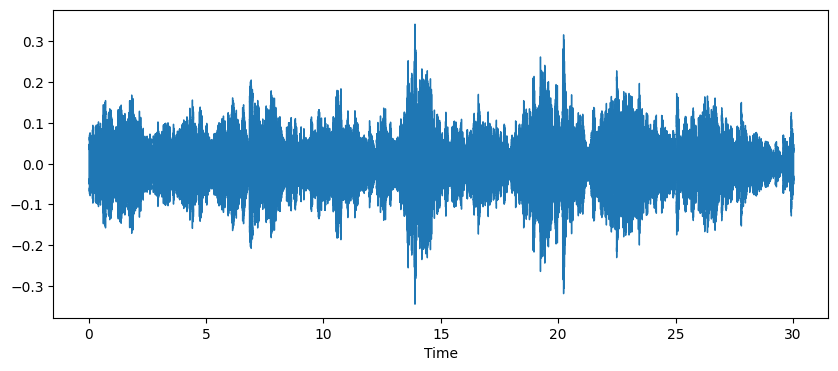

In [ ]:
plt.figure(figsize=(10,4))
x,sr = librosa.load('/content/drive/MyDrive/MusicGenre/genres_original/classical/classical.00000.wav')
librosa.display.waveshow(x, sr=sr)

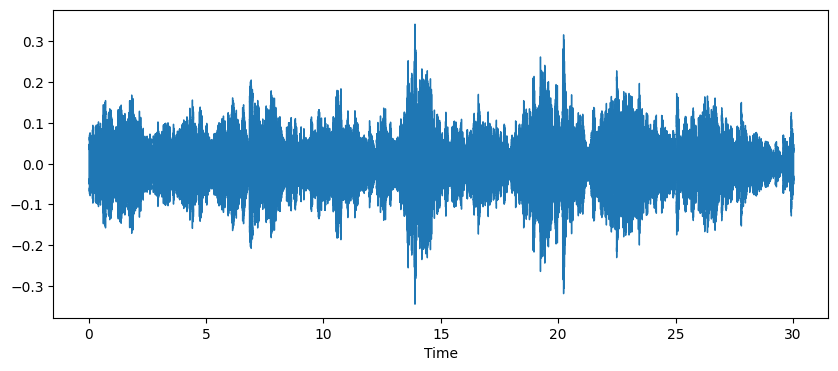

In [ ]:
plt.figure(figsize=(10,4))
x,sr = librosa.load('/content/drive/MyDrive/MusicGenre/genres_original/classical/classical.00000.wav')
librosa.display.waveshow(x, sr=sr)

LIBROSA

In [ ]:
corr_cols = [cols for cols in df.columns if 'mean' in cols]

Text(0.5, 1.0, 'Heatmap for variables (correlation matrix)')

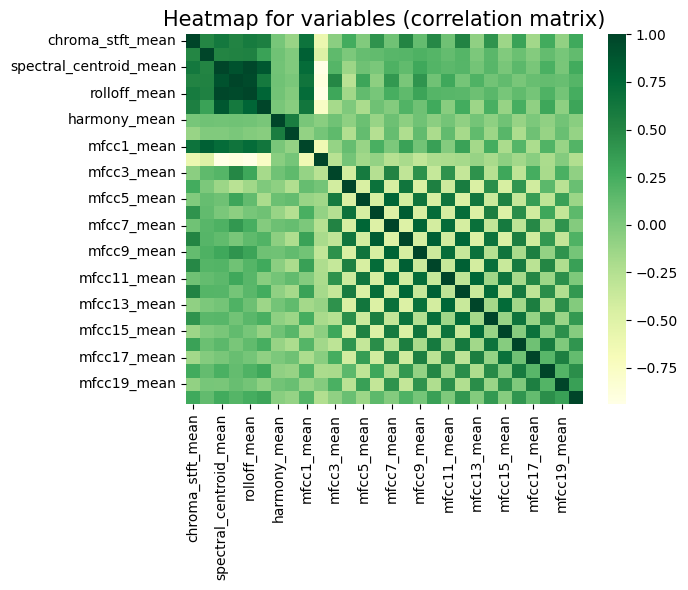

In [ ]:
plt.plot(figsize = (10, 10))
sns.heatmap(df[corr_cols].corr(), cmap = 'YlGn')
plt.title('Heatmap for variables (correlation matrix)', fontsize = 15)

DATA PREPROCESSING

In [ ]:
from sklearn import preprocessing

In [ ]:
label_enc = preprocessing.LabelEncoder()
df['label'] = label_enc.fit_transform(df['label'])

In [ ]:
df.head()

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,0
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,0
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,0
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,0
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,0


In [ ]:
x = df.drop(['filename','label'], axis = 1)
y = df['label']
x.head()

,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
0,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,3805.839606,...,0.752740,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035
1,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,3550.522098,...,0.927998,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282
2,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,3042.260232,...,2.451690,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025
3,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,2184.745799,...,0.780874,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339
4,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,3579.757627,...,-4.520576,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160


In [ ]:
cols = x.columns
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x = scaler.fit_transform(x)
x = pd.DataFrame(x, columns = [cols])

SPLITTING INTO X AND Y

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [ ]:
x_test

,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
521,0.113487,0.530290,0.668097,0.108737,0.014698,0.606689,0.151234,0.582925,0.065221,0.645238,...,0.865347,0.112723,0.391130,0.076799,0.523223,0.131693,0.456358,0.144647,0.635667,0.101597
737,0.095142,0.569168,0.640396,0.600230,0.290188,0.690306,0.207120,0.787286,0.228599,0.750735,...,0.517666,0.099255,0.524310,0.063629,0.378879,0.114687,0.538777,0.115436,0.449897,0.090596
740,0.095142,0.244689,0.645340,0.494151,0.203332,0.360135,0.083659,0.546392,0.246486,0.387370,...,0.655481,0.166132,0.581028,0.165697,0.416612,0.226865,0.576738,0.139701,0.507940,0.199356
660,0.113487,0.749188,0.236134,0.306812,0.022797,0.451536,0.035438,0.447463,0.038462,0.487712,...,0.608750,0.033225,0.362977,0.028023,0.591481,0.000000,0.454885,0.018046,0.614511,0.018982
411,0.113487,0.553279,0.639556,0.505471,0.238303,0.394644,0.139456,0.514246,0.146212,0.483407,...,0.700832,0.176476,0.502206,0.223610,0.685942,0.291490,0.382510,0.238070,0.457868,0.169222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408,0.113487,0.572824,0.684102,0.347733,0.283481,0.646983,0.292548,0.555833,0.136457,0.631301,...,0.774597,0.250695,0.616753,0.358480,0.912380,0.378873,0.736443,0.336869,0.718732,0.278569
332,0.113487,0.399405,0.721172,0.269411,0.158892,0.485583,0.159292,0.593929,0.299107,0.530857,...,0.542582,0.181684,0.563407,0.168174,0.601781,0.306830,0.527851,0.162171,0.415666,0.225490
208,0.236589,0.372882,0.604446,0.685617,0.037027,0.500794,0.090660,0.641846,0.158487,0.596683,...,0.603524,0.173463,0.685798,0.160243,0.671150,0.306995,0.456375,0.155939,0.743365,0.131549
613,0.095142,0.944128,0.000000,0.206413,0.005404,0.640979,0.035767,0.538144,0.010993,0.628917,...,0.900464,0.036045,0.255206,0.026381,0.622167,0.010202,0.396281,0.014131,0.672170,0.020721


In [ ]:
x_train

,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
29,0.113487,0.220475,0.960818,0.304204,0.173732,0.279104,0.232568,0.494689,0.255132,0.379736,...,0.253292,0.195535,0.203719,0.215243,0.191583,0.255783,0.255698,0.159809,0.167242,0.140481
535,0.113487,0.188433,0.714777,0.219546,0.044332,0.070900,0.014339,0.079015,0.022693,0.108387,...,0.576966,0.088657,0.531394,0.055876,0.246577,0.156325,0.501112,0.077155,0.465340,0.092238
695,0.113487,0.726479,0.382646,0.458803,0.136446,0.485415,0.082283,0.548688,0.065832,0.560465,...,0.858214,0.059567,0.370036,0.050200,0.565301,0.103901,0.458337,0.064113,0.668138,0.047715
557,0.113487,0.126546,0.756634,0.185536,0.082339,0.209170,0.052962,0.335280,0.111277,0.231539,...,0.399481,0.104241,0.547965,0.150885,0.308701,0.248987,0.370952,0.264297,0.356627,0.166707
836,0.113487,0.534238,0.771763,0.190243,0.114451,0.321047,0.213458,0.485612,0.250776,0.424932,...,0.722968,0.158150,0.610115,0.174856,0.620740,0.131561,0.547257,0.159955,0.540346,0.111548
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.113487,0.182076,0.638184,0.071147,0.012436,0.207647,0.020631,0.260818,0.028278,0.250812,...,0.616173,0.197364,0.536436,0.215316,0.330367,0.267435,0.561544,0.195542,0.655300,0.189949
270,0.113487,0.393271,0.657055,0.354231,0.101171,0.353075,0.079948,0.410510,0.128575,0.416122,...,0.594906,0.143757,0.344071,0.088158,0.456352,0.093316,0.513430,0.059816,0.397000,0.071444
860,0.095142,0.258553,0.741660,0.052330,0.012185,0.472277,0.280986,0.537018,0.204266,0.509863,...,0.564509,0.126287,0.288101,0.213886,0.340377,0.090864,0.391863,0.142524,0.326536,0.120603
435,0.514929,0.727257,0.640439,0.475531,0.306195,0.583965,0.362659,0.741297,0.228111,0.687059,...,0.694836,0.087745,0.517444,0.073665,0.636629,0.109802,0.641395,0.080578,0.668115,0.071584


MODEL TRAINING THROUGH LOGISTIC REGRESSION AND EVALUTON

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
model = LogisticRegression(random_state = 50)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
accuracy_score(y_test, y_pred)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.61

In [ ]:
y_pred

array([3, 7, 7, 6, 4, 6, 6, 5, 8, 1, 3, 0, 6, 6, 7, 6, 9, 8, 7, 8, 0, 1,
       3, 5, 2, 2, 1, 3, 4, 8, 3, 1, 6, 4, 6, 1, 6, 5, 0, 6, 3, 0, 3, 9,
       0, 2, 9, 6, 4, 8, 5, 8, 2, 5, 5, 0, 6, 0, 2, 8, 0, 6, 5, 7, 6, 0,
       6, 8, 9, 0, 1, 6, 5, 2, 6, 2, 6, 0, 5, 3, 6, 9, 9, 9, 7, 5, 0, 2,
       7, 8, 4, 4, 5, 2, 7, 4, 7, 0, 9, 8, 7, 6, 9, 0, 6, 6, 5, 9, 1, 6,
       5, 4, 9, 6, 8, 8, 1, 0, 5, 0, 8, 4, 8, 2, 2, 5, 5, 4, 2, 3, 5, 2,
       0, 9, 5, 6, 1, 9, 5, 9, 0, 5, 7, 2, 8, 8, 0, 2, 4, 3, 6, 1, 3, 4,
       9, 4, 9, 6, 6, 0, 5, 7, 6, 6, 4, 6, 0, 0, 3, 7, 3, 8, 1, 9, 4, 4,
       0, 0, 2, 6, 4, 3, 9, 5, 8, 1, 9, 4, 9, 7, 5, 0, 6, 1, 3, 4, 3, 7,
       6, 6])

In [ ]:
y_test

,label
521,5
737,7
740,7
660,6
411,4
...,...
408,4
332,3
208,2
613,6


In [ ]:
a = list(y_test)
for i in range(len(a)):
  print(a, end = " ")

[5, 7, 7, 6, 4, 6, 6, 5, 8, 1, 8, 0, 6, 9, 9, 8, 2, 8, 7, 3, 5, 1, 3, 5, 2, 2, 1, 9, 9, 9, 3, 1, 6, 4, 3, 1, 6, 5, 9, 0, 3, 0, 3, 9, 2, 2, 9, 6, 4, 8, 5, 8, 2, 5, 0, 0, 6, 0, 2, 8, 2, 0, 5, 2, 6, 6, 6, 8, 0, 5, 1, 4, 5, 7, 2, 2, 6, 0, 5, 3, 6, 0, 2, 0, 3, 5, 9, 7, 7, 3, 3, 4, 5, 2, 7, 4, 7, 0, 0, 8, 7, 3, 9, 2, 6, 6, 5, 9, 1, 9, 5, 8, 9, 8, 0, 4, 1, 9, 5, 2, 8, 4, 7, 2, 2, 5, 5, 4, 8, 8, 5, 8, 2, 9, 5, 0, 1, 2, 0, 0, 0, 2, 7, 2, 8, 9, 8, 2, 8, 3, 6, 1, 9, 4, 9, 4, 3, 6, 0, 8, 5, 7, 6, 6, 8, 6, 2, 6, 3, 3, 3, 4, 1, 9, 4, 3, 2, 2, 8, 6, 4, 6, 3, 5, 8, 1, 3, 3, 9, 7, 9, 8, 6, 1, 2, 4, 3, 2, 6, 0] [5, 7, 7, 6, 4, 6, 6, 5, 8, 1, 8, 0, 6, 9, 9, 8, 2, 8, 7, 3, 5, 1, 3, 5, 2, 2, 1, 9, 9, 9, 3, 1, 6, 4, 3, 1, 6, 5, 9, 0, 3, 0, 3, 9, 2, 2, 9, 6, 4, 8, 5, 8, 2, 5, 0, 0, 6, 0, 2, 8, 2, 0, 5, 2, 6, 6, 6, 8, 0, 5, 1, 4, 5, 7, 2, 2, 6, 0, 5, 3, 6, 0, 2, 0, 3, 5, 9, 7, 7, 3, 3, 4, 5, 2, 7, 4, 7, 0, 0, 8, 7, 3, 9, 2, 6, 6, 5, 9, 1, 9, 5, 8, 9, 8, 0, 4, 1, 9, 5, 2, 8, 4, 7, 2, 2, 5, 5, 4, 8, 8, 5, 8, 2,

MODEL TRAINING THROUGH K-NEIGHBOUR AND EVALUATION


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors = 5)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
accuracy_score(y_test, y_pred)

0.69

GRADIENT BOOST: combines various weak models to increase the accuracy of

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize the model with a fixed number of boosting stages (acts like epochs)
model = GradientBoostingClassifier(n_estimators=50, random_state=50)  # 50 boosting stages

# Train the model
model.fit(x_train, y_train)

# Evaluate accuracy
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")


Accuracy: 0.745


ACCURACY GRAPH

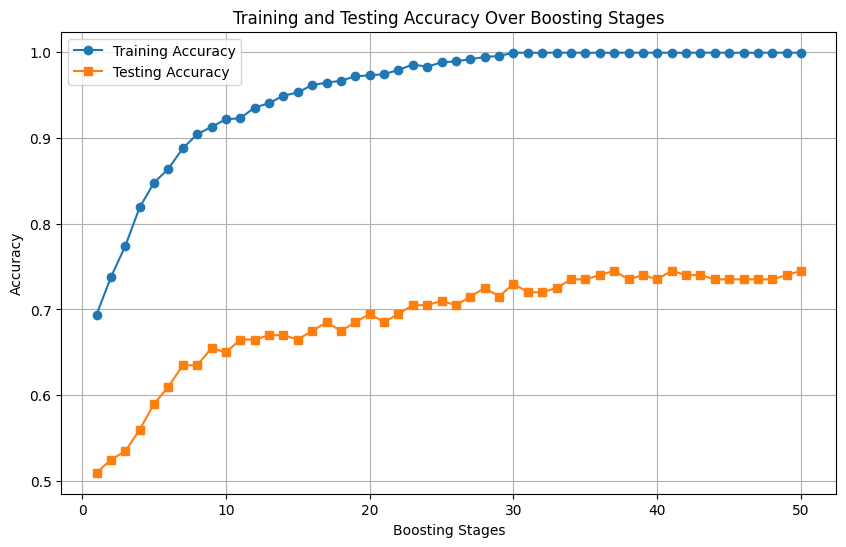

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Initialize the GradientBoostingClassifier
model = GradientBoostingClassifier(n_estimators=50, random_state=50)

# Train the model
model.fit(x_train, y_train)

# Initialize lists to store accuracy at each boosting stage
train_acc = []
test_acc = []

# Evaluate accuracy after each boosting stage using staged_predict
for y_train_pred, y_test_pred in zip(model.staged_predict(x_train), model.staged_predict(x_test)):
    train_acc.append(accuracy_score(y_train, y_train_pred))
    test_acc.append(accuracy_score(y_test, y_test_pred))

# Plot accuracy over boosting stages
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_acc) + 1), train_acc, label='Training Accuracy', marker='o')
plt.plot(range(1, len(test_acc) + 1), test_acc, label='Testing Accuracy', marker='s')
plt.xlabel('Boosting Stages')
plt.ylabel('Accuracy')
plt.title('Training and Testing Accuracy Over Boosting Stages')
plt.legend()
plt.grid()
plt.show()


NEURAL NETWORKS: - implementing MLP (FNN) through Tensorflow/Keras
                 - applying 100 epoch
                 - getting accuracy
              

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.1416 - loss: 2.2820 - val_accuracy: 0.2688 - val_loss: 2.1696
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3488 - loss: 2.1318 - val_accuracy: 0.3187 - val_loss: 2.0426
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3596 - loss: 1.9659 - val_accuracy: 0.3250 - val_loss: 1.8802
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3752 - loss: 1.8151 - val_accuracy: 0.4187 - val_loss: 1.7211
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3943 - loss: 1.6599 - val_accuracy: 0.4375 - val_loss: 1.6119
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4982 - loss: 1.5214 - val_accuracy: 0.4375 - val_loss: 1.4911
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4667 - loss: 1.4572 - val_accuracy: 0.4812 - val_loss: 1.4302
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5315 - loss: 1.3145 - val_accuracy: 0.4812 - val_loss: 1.

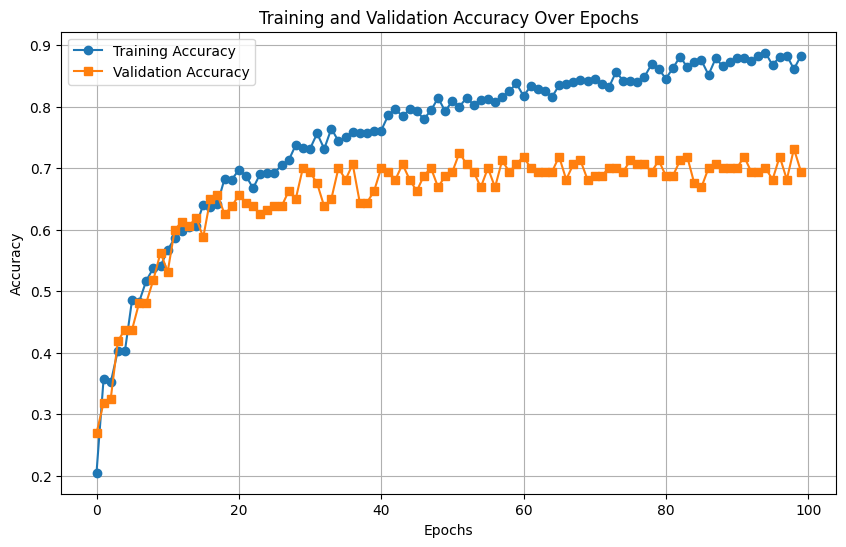

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7536 - loss: 1.0067  
Test Accuracy: 0.7350000143051147


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Convert labels to categorical if multi-class classification
num_classes = len(y_train.unique())  # Adjust for the number of classes
y_train_categorical = to_categorical(y_train, num_classes)
y_test_categorical = to_categorical(y_test, num_classes)

# Define the Neural Network model
model = Sequential([
    Dense(121, activation='relu', input_shape=(x_train.shape[1],)),#inputlayer
    Dense(64, activation='relu'),
                                     #Hiddenlayer
    Dense(num_classes, activation='softmax')                      #Outputlayer
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model with epochs
history = model.fit(x_train, y_train_categorical, epochs=100, batch_size=32, validation_split=0.2)

# Plot training and validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy Over Epochs')
plt.legend()
plt.grid()
plt.show()

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(x_test, y_test_categorical)
print(f"Test Accuracy: {test_accuracy}")
